In [24]:
import os
import math
import cv2
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from utils import Extractor
from circle_fit import taubinSVD
from paddleocr import PaddleOCR

In [25]:
ppocr = PaddleOCR(det_model_dir='models/ch_PP-OCRv3_det_infer',
                rec_model_dir='models/ch_PP-OCRv3_rec_infer',
                cls_model_dir='models/ch_ppocr_mobile_v2.0_cls_infer', 
                use_angle_cls=True)

[2023/01/18 11:16:36] ppocr DEBUG: Namespace(alpha=1.0, benchmark=False, beta=1.0, cls_batch_num=6, cls_image_shape='3, 48, 192', cls_model_dir='models/ch_ppocr_mobile_v2.0_cls_infer', cls_thresh=0.9, cpu_threads=10, crop_res_save_dir='./output', det=True, det_algorithm='DB', det_box_type='quad', det_db_box_thresh=0.6, det_db_score_mode='fast', det_db_thresh=0.3, det_db_unclip_ratio=1.5, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_east_score_thresh=0.8, det_limit_side_len=960, det_limit_type='max', det_model_dir='models/ch_PP-OCRv3_det_infer', det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, det_pse_thresh=0, det_sast_nms_thresh=0.2, det_sast_score_thresh=0.5, draw_img_save_dir='./inference_results', drop_score=0.5, e2e_algorithm='PGNet', e2e_char_dict_path='./ppocr/utils/ic15_dict.txt', e2e_limit_side_len=768, e2e_limit_type='max', e2e_model_dir=None, e2e_pgnet_mode='fast', e2e_pgnet_score_thresh=0.5, e2e_pgnet_valid_set='totaltext', enable_mkldnn=False, four

In [26]:
extractor = Extractor()
extractor.load_model()

# GG Home Mini

In [312]:
def extract(img):

    img = cv2.rotate(img,cv2.ROTATE_180)
    
    k = 45
    kernel = np.ones((k,k),np.uint8)

    mask = extractor.get_mask(img)
    dilate = cv2.dilate(mask.astype('uint8')*255,kernel,iterations=1)

    img_resize = cv2.resize(img,(mask.shape[1],mask.shape[0]))
    
    w,h = dilate.shape

    v_lines = []
    c = []
    for i in range(w):
        v_line = dilate[:,i:i+1]
        pos = cv2.findNonZero(v_line) #x,y
        if pos is not None:
            c.append((i,pos[0][0][-1]))
        v_lines.append(v_line)

    C= []
    c_sub = []
    p0 = c[0]
    DMAX = 80
    for i in range(len(c)):
        p = c[i]
        c_sub.append(p)
        d = cv2.norm(np.array(p),np.array(p0))
        if d > DMAX:
            C.append(c_sub)
            c_sub = []
            #print(p0)
        p0 = p

    C.append(c_sub) # the final c_sub is your circle

    L = [len(i) for i in C]
    c_sub = C[np.argmax(L)]
    
    xc, yc, r, sigma = taubinSVD(c_sub)
    r = int(r) +100
    d = r*2
    cp = (int(xc),int(yc))
    warped = cv2.warpPolar(img_resize,(d,int(d * math.pi)),cp,r,0)
    
    straightened = cv2.rotate(warped,cv2.ROTATE_90_COUNTERCLOCKWISE)
    im = np.hstack([straightened,straightened])
    im = im[:,2500:8000]
    cv2.imwrite('debug.jpg',im)
    im = im + 0.2 * im
    res = ppocr.ocr(im,det=True,rec=True,cls=False)
    
    return res

In [313]:
def infer(res):
    model = 'n/a'
    serial = 'n/a'
    for r in res[0]:
        t=r[1][0].lower()
        # infer model
        count = t.count('h2c')
        if count >= 1:
            model = 'H2C'
        # infer serial 14 digit
        if len(t)>=14:
            for i in range(len(t)):
                s = t[i:i+14]
                if all([c.isalnum() for c in s])\
                and all([c.isnumeric() for c in s[:4]])\
                and serial =='n/a':
                    serial = s
    return model,serial

# survey

- ok: 1,3,6,7,10,11,12,13,14,15,16,18
- mistake: 2,4,5,8,9
- dismiss: 17
- fail:

edit light condition

In [314]:
file = 'album2/img2.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model,model.upper()=="H2C"," Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/18 14:15:39] ppocr DEBUG: dt_boxes num : 7, elapse : 0.16127848625183105
[2023/01/18 14:15:39] ppocr DEBUG: rec_res num  : 7, elapse : 0.2865779399871826
[[[[[36.0, 70.0], [1216.0, 95.0], [1213.0, 232.0], [33.0, 206.0]], ('MadeinThailand 05041HFAP6VYBO', 0.8211672306060791)], [[[4462.0, 120.0], [5480.0, 87.0], [5484.0, 229.0], [4466.0, 262.0]], ('Modelt H2C GocgleFCCID.A', 0.826526939868927)], [[[2486.0, 1278.0], [2641.0, 1278.0], [2641.0, 1384.0], [2486.0, 1384.0]], ('Sn', 0.595569908618927)]]] 


Img:  album2/img2.jpg  Model:  H2C True  Serial( 14 ): 05041HFAP6VYBO True


# orignal

In [256]:
file = 'album2/img17.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model.upper(),model.upper()=="H2C",
      " Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/18 13:54:16] ppocr DEBUG: dt_boxes num : 1, elapse : 0.14166998863220215
[2023/01/18 13:54:16] ppocr DEBUG: rec_res num  : 1, elapse : 0.15192341804504395
[[[[[911.0, 94.0], [4824.0, 107.0], [4824.0, 243.0], [911.0, 230.0]], ('Modet:H2CGoogleFCCID:A4R-H2CIC:10395A-H2C CANICES-3(B)/NMB-3(B)Made in Thailand05041HFAP6VYBO', 0.8946219086647034)]]] 


Img:  album2/img17.jpg  Model:  H2C True  Serial( 14 ): 05041HFAP6VYBO True


# cut

In [268]:
file = 'album2/aug1.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model.upper(),model.upper()=="H2C",
      " Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/18 13:56:42] ppocr DEBUG: dt_boxes num : 1, elapse : 0.1467437744140625
[2023/01/18 13:56:42] ppocr DEBUG: rec_res num  : 1, elapse : 0.04698991775512695
[[[[[719.0, 158.0], [2029.0, 189.0], [2025.0, 366.0], [715.0, 335.0]], ('ModetH2CGOgleFCCDA4R-H20', 0.860751211643219)]]] 


Img:  album2/aug1.jpg  Model:  H2C True  Serial( 2 ): 20 False


# rotated

In [269]:
file = 'album2/aug2.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model.upper(),model.upper()=="H2C",
      " Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/18 13:57:13] ppocr DEBUG: dt_boxes num : 0, elapse : 0.15627288818359375
[2023/01/18 13:57:13] ppocr DEBUG: rec_res num  : 0, elapse : 1.430511474609375e-06
[[]] 


Img:  album2/aug2.jpg  Model:  N/A False  Serial( 3 ): N/A False


# vertical skew

In [270]:
file = 'album2/aug3.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model.upper(),model.upper()=="H2C",
      " Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/18 13:57:43] ppocr DEBUG: dt_boxes num : 0, elapse : 0.18654632568359375
[2023/01/18 13:57:43] ppocr DEBUG: rec_res num  : 0, elapse : 1.1920928955078125e-06
[[]] 


Img:  album2/aug3.jpg  Model:  N/A False  Serial( 3 ): N/A False


# horizontal skew

In [271]:
file = 'album2/aug4.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model.upper(),model.upper()=="H2C",
      " Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/18 13:58:03] ppocr DEBUG: dt_boxes num : 0, elapse : 0.14921116828918457
[2023/01/18 13:58:03] ppocr DEBUG: rec_res num  : 0, elapse : 1.430511474609375e-06
[[]] 


Img:  album2/aug4.jpg  Model:  N/A False  Serial( 3 ): N/A False


# low brightness

In [261]:
file = 'album2/aug5.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model.upper(),model.upper()=="H2C",
      " Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/18 13:54:47] ppocr DEBUG: dt_boxes num : 1, elapse : 0.13924527168273926
[2023/01/18 13:54:47] ppocr DEBUG: rec_res num  : 1, elapse : 0.18030786514282227
[[[[[911.0, 106.0], [4818.0, 112.0], [4818.0, 237.0], [911.0, 230.0]], ('Model:H2C GocgleFCCID:A4R-H2CIC:10395A-H2CCANICES-3(B)/NMB-3(B)Made inThaiand05041HFAP6VYBO', 0.8969592452049255)]]] 


Img:  album2/aug5.jpg  Model:  H2C True  Serial( 14 ): 05041HFAP6VYBO True


# noise

In [277]:
file = 'album2/aug7.jpg'

img = cv2.imread(file)

res = extract(img)
print(res,'\n\n')

model,serial = infer(res)

print("Img: ",file," Model: ",model.upper(),model.upper()=="H2C",
      " Serial(",len(serial),"):",serial.upper(),serial.upper()=="05041HFAP6VYBO")

[2023/01/18 14:07:55] ppocr DEBUG: dt_boxes num : 0, elapse : 0.15201282501220703
[2023/01/18 14:07:55] ppocr DEBUG: rec_res num  : 0, elapse : 9.5367431640625e-07
[[]] 


Img:  album2/aug7.jpg  Model:  N/A False  Serial( 3 ): N/A False


# step by step

img shape: (3684, 4912, 3)
mask shape: (3104, 4192)


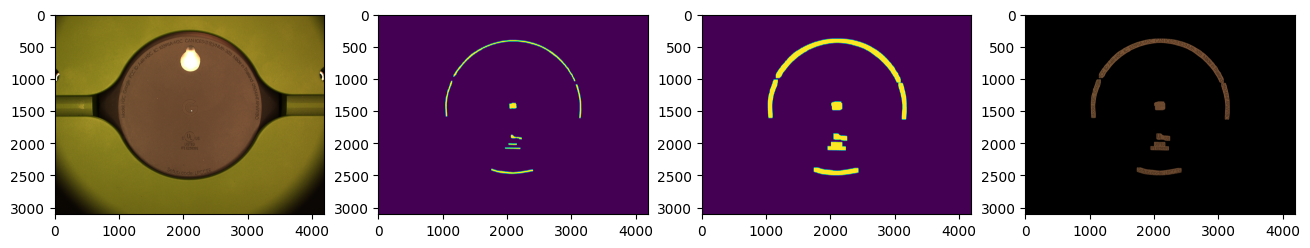

In [238]:
#dilate
k = 45
kernel = np.ones((k,k),np.uint8)

img = cv2.imread('album2/img16.jpg')
img = cv2.rotate(img,cv2.ROTATE_180)

mask = extractor.get_mask(img)
dilate = cv2.dilate(mask.astype('uint8')*255,kernel,iterations=1)
print("img shape:",img.shape)
print("mask shape:",mask.shape)

img_resize = cv2.resize(img,(mask.shape[1],mask.shape[0]))

# and mask
res = cv2.bitwise_and(img_resize,img_resize,mask=dilate)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16,10))
axes[0].imshow(img_resize)
axes[1].imshow(mask)
axes[2].imshow(dilate)
axes[3].imshow(res)

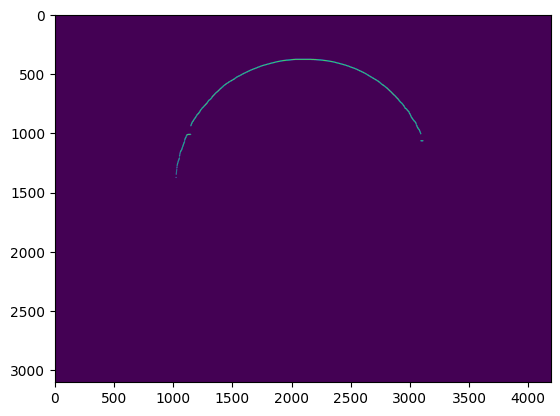

In [239]:
w,h = dilate.shape

v_lines = []
c = []
for i in range(w):
    v_line = dilate[:,i:i+1]
    pos = cv2.findNonZero(v_line) #x,y
    if pos is not None:
        c.append((i,pos[0][0][-1]))
    v_lines.append(v_line)
    
blank = np.zeros_like(dilate)

C= []
c_sub = []
p0 = c[0]
DMAX = 80
for i in range(len(c)):
    p = c[i]
    c_sub.append(p)
    d = cv2.norm(np.array(p),np.array(p0))
    if d > DMAX:
        C.append(c_sub)
        c_sub = []
        print(p0)
    p0 = p
    
C.append(c_sub) # the final c_sub is your circle

L = [len(i) for i in C]
c_sub = C[np.argmax(L)]

blank = np.zeros_like(dilate)
for p in c_sub:
    cv2.circle(blank,(p[0], p[1]), 3, (255,255,255), -1)
plt.imshow(blank)

xc=2101, yc=1460, r=1134, sigma=4.328501652022898


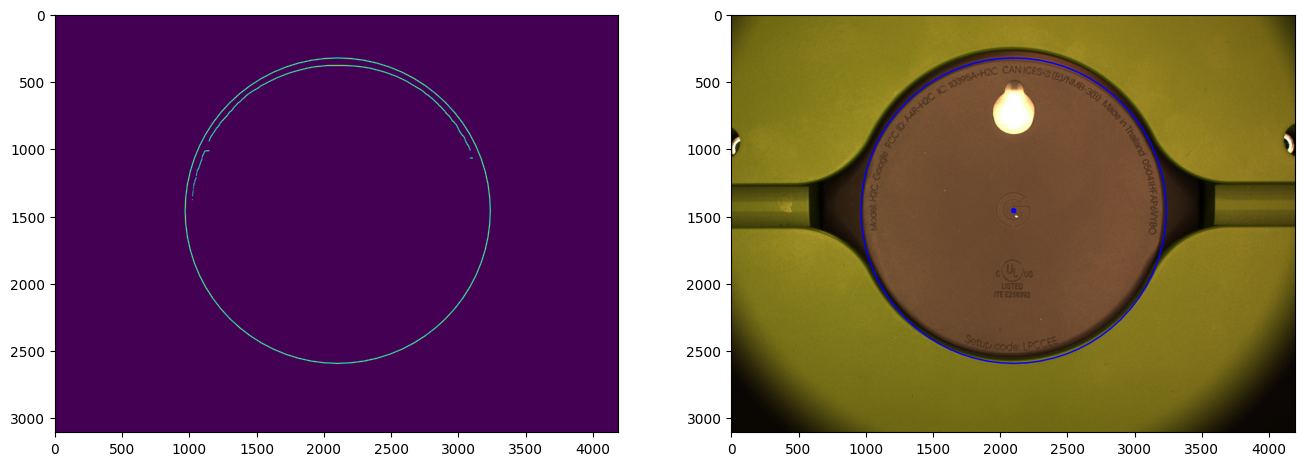

In [240]:
xc, yc, r, sigma = taubinSVD(c_sub)
r = int(r) +50
d = r*2
print(f"xc={int(xc)}, yc={int(yc)}, r={int(r)}, sigma={sigma}") #217330,1739

cv2.circle(blank,(int(xc),int(yc)),int(r),(255),6)
cv2.circle(img_resize,(int(xc),int(yc)),20,(0,0,255),-1)
cv2.circle(img_resize,(int(xc),int(yc)),r,(0,0,255),10)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16,10))
axes[0].imshow(blank)
axes[1].imshow(img_resize)

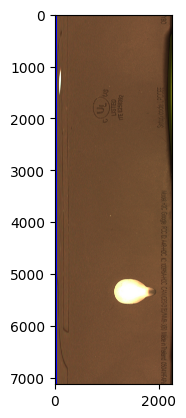

In [241]:
cp = (int(xc),int(yc))
warped = cv2.warpPolar(img_resize,(d,int(d * math.pi)),cp,r,0)
plt.imshow(warped)

[2023/01/18 13:50:25] ppocr DEBUG: dt_boxes num : 1, elapse : 0.1394670009613037
[2023/01/18 13:50:25] ppocr DEBUG: rec_res num  : 1, elapse : 0.14720654487609863
[[[[[894.0, 94.0], [4818.0, 106.0], [4818.0, 242.0], [894.0, 230.0]], ('ModetH2C GocgleFCCID:A4R-H2C IC:10395A-H2CCANICES-3(B)/NMB-3(B)Madein Thaiand05041HFAP6VYBO', 0.9124192595481873)]]] 



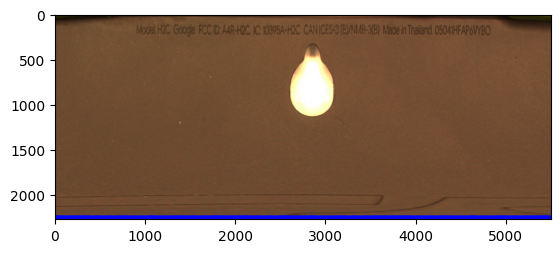

In [242]:
straightened = cv2.rotate(warped,cv2.ROTATE_90_COUNTERCLOCKWISE)
im = np.hstack([straightened,straightened])
im = im[:,2500:8000]
cv2.imwrite('straight.jpg',im)
res1 = ppocr.ocr(im,det=True,rec=True,cls=False)
print(res1,"\n")
plt.imshow(im)

In [243]:
serial = 'n/a'

res = extract(img)
print(res)

for r in res[0]:

    t=r[1][0].lower()
    # infer model
    count = t.count('h2c')
    if count > 1:
        model = 'H2C'
    # infer serial 14 digit
    if len(t)>14:
        for i in range(len(t)):
            s = t[i:i+14]
            if len(s) == 14\
                and all([c.isalnum() for c in s])\
                and all([c.isnumeric() for c in s[:4]]):
                serial = s
                
print("Model: ",model,"Serial: ",serial.upper())

[2023/01/18 13:50:29] ppocr DEBUG: dt_boxes num : 6, elapse : 0.14148616790771484
[2023/01/18 13:50:29] ppocr DEBUG: rec_res num  : 6, elapse : 0.2861475944519043
[[[[[42.0, 46.0], [1227.0, 78.0], [1224.0, 213.0], [39.0, 182.0]], ('Made in Thaiand 05041HFAP6VYBO', 0.9404473900794983)], [[[4461.0, 131.0], [5474.0, 93.0], [5479.0, 234.0], [4466.0, 273.0]], ('Modet H2C Gocgle FCC ID:A', 0.8741166591644287)], [[[2475.0, 1281.0], [2578.0, 1281.0], [2578.0, 1357.0], [2475.0, 1357.0]], ('Sr', 0.5927064418792725)]]]
Model:  H2C Serial:  05041HFAP6VYBO


In [244]:
def extract(img):
    
    # 7,10,11,13 (None)
    # 2,6,8,9,15 (1=i)
    # 1,3,4,5,12,14
    img = cv2.rotate(img,cv2.ROTATE_180)
    
    k = 45
    kernel = np.ones((k,k),np.uint8)

    mask = extractor.get_mask(img)
    dilate = cv2.dilate(mask.astype('uint8')*255,kernel,iterations=1)

    img_resize = cv2.resize(img,(mask.shape[1],mask.shape[0]))
    
    w,h = dilate.shape

    v_lines = []
    c = []
    for i in range(w):
        v_line = dilate[:,i:i+1]
        pos = cv2.findNonZero(v_line) #x,y
        if pos is not None:
            c.append((i,pos[0][0][-1]))
        v_lines.append(v_line)

    C= []
    c_sub = []
    p0 = c[0]
    DMAX = 80
    for i in range(len(c)):
        p = c[i]
        c_sub.append(p)
        d = cv2.norm(np.array(p),np.array(p0))
        if d > DMAX:
            C.append(c_sub)
            c_sub = []
            print(p0)
        p0 = p

    C.append(c_sub) # the final c_sub is your circle

    L = [len(i) for i in C]
    c_sub = C[np.argmax(L)]
    
    xc, yc, r, sigma = taubinSVD(c_sub)
    r = int(r) +50
    d = r*2
    cp = (int(xc),int(yc))
    warped = cv2.warpPolar(img_resize,(d,int(d * math.pi)),cp,r,0)
    
    straightened = cv2.rotate(warped,cv2.ROTATE_90_COUNTERCLOCKWISE)
    im = np.hstack([straightened,straightened])
    im = im[:,2500:8000]
    
    res = ppocr.ocr(im,det=True,rec=True,cls=False)
    
    return res

[2023/01/18 10:11:21] ppocr DEBUG: dt_boxes num : 1, elapse : 0.13804841041564941
[2023/01/18 10:11:21] ppocr DEBUG: rec_res num  : 1, elapse : 0.1412496566772461
[[[[[894.0, 94.0], [4813.0, 100.0], [4812.0, 242.0], [894.0, 236.0]], ('ModetH2CGocgleFCCID:A4R-H2CIC:10395A-H2CCANICES-3(B)/NMB-3(B)MadeinThailand0504HFAP6VYBO', 0.929810106754303)]]]
Model:  H2C Serial:  None


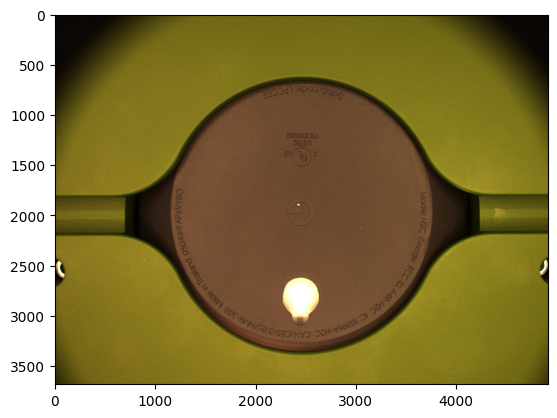

In [19]:
##### model = None
serial = None

# 7,10,11,13 (None)
# 2,6,8,9,15 (1=i)
# 1,3,4,5,12,14

img = cv2.imread(f'album2/img16.jpg')

plt.imshow(img)
res = extract(img)

print(res)

for r in res[0]:

    t=r[1][0].lower()
    # infer model
    count = t.count('h2c')
    if count > 1:
        model = 'H2C'
    # infer serial 14 digit
    if len(t)>14:
        for i in range(len(t)):
            s = t[i:i+14]
            if len(s) == 14\
                and all([c.isalnum() for c in s])\
                and all([c.isnumeric() for c in s[:4]]):
                serial = s
                
    print("Model: ",model,"Serial: ",serial)

# ring to rectangle

Text(0.5, 1.0, '(588, 588, 3)')

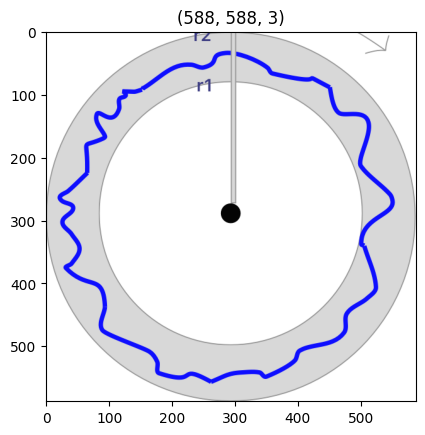

In [43]:
ring = cv2.imread('snippets/ring.png')
plt.imshow(ring)
plt.title(ring.shape)

In [44]:
factor = 0.7
size = ring.shape[0]
outer_radius = size // 2
inner_radius = int(factor*outer_radius)
print(f'outer_radius: {outer_radius}')
print(f'inner_radius: {inner_radius}')

outer_radius: 294
inner_radius: 205


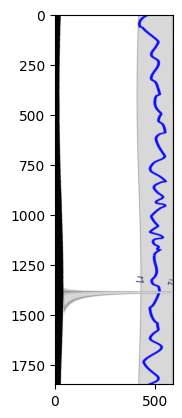

In [45]:
# Unwarp ring
cp = (outer_radius,outer_radius)
warped = cv2.warpPolar(ring, (size, int(size * math.pi)),cp, outer_radius, 0)
plt.imshow(warped)

Text(0.5, 1.0, '(588, 1847, 3)')

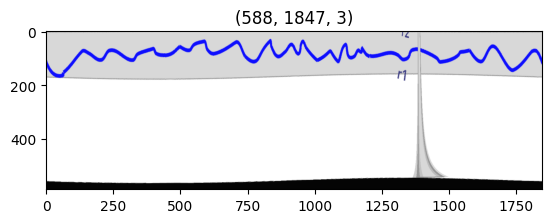

In [46]:
straightened = cv2.rotate(warped,cv2.ROTATE_90_COUNTERCLOCKWISE)
plt.imshow(straightened)
plt.title(straightened.shape)

True

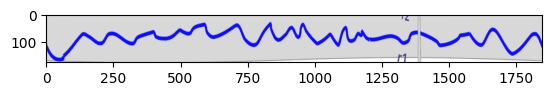

In [47]:
# Crop to ring only
cropped = straightened[: int(straightened.shape[0] * (1 - factor)), :]
plt.imshow(cropped)
cv2.imwrite("straight.png", cropped)

# references

[ring-to-a-rectangle](https://stackoverflow.com/questions/71416458/how-to-map-points-from-a-surface-of-2d-ring-to-a-rectangle)

[using-dilation-in-only-one-direction](https://stackoverflow.com/questions/59050090/using-dilation-in-only-one-direction)

[straightening-contoured-rectangles](https://stackoverflow.com/questions/42879716/straightening-contoured-rectangles-in-opencv-python)

[How to convert curves in images to lines in Python?](https://stackoverflow.com/questions/61725926/how-to-convert-curves-in-images-to-lines-in-python)

[paddleocr](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/paddleocr.py)